# 🌳 Decision Tree Implementation in Python : PlayTennis Dataset (ID3 Algorithm)

**Name:** Lakshay  
**Roll No:** AP24110010677  
**Course:** Machine Learning Lab  
**Random seed:** `77` (last two digits of roll number)

---

### Aim
To build a Decision Tree classifier for the classic **PlayTennis** dataset (Tom Mitchell, *Machine Learning*, Ch. 3) by:
1. Calculating **Entropy** and **Information Gain** by hand (step by step, in code)
2. Implementing the **ID3 algorithm from scratch** in Python
3. Visualising the tree, extracting **IF–THEN rules**, and predicting new days
4. Comparing with **scikit-learn's `DecisionTreeClassifier`** (Entropy and Gini)
5. Evaluating the model and discussing **overfitting and pruning**

## 1. Theory

### 1.1 What is a Decision Tree?
A decision tree is a supervised learning model that classifies an instance by asking a sequence of questions about its attributes.
- **Internal node** → tests an attribute (e.g. *Outlook?*)
- **Branch** → one value of that attribute (e.g. *Sunny*)
- **Leaf node** → final class label (e.g. *Yes / No*)

Every path from root to leaf is a conjunction of conditions, so the whole tree is a **disjunction of conjunctions** (a set of IF–THEN rules).

### 1.2 Entropy : measuring impurity
For a set $S$ with $c$ classes:

$$Entropy(S) = -\sum_{i=1}^{c} p_i \log_2 p_i$$

- $p_i$ = proportion of examples in $S$ belonging to class $i$
- Entropy = **0** → set is pure (all one class)
- Entropy = **1** → maximum impurity for 2 classes (50/50 split)
- By convention $0 \log_2 0 = 0$

### 1.3 Information Gain : choosing the best attribute
$$Gain(S, A) = Entropy(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|}\, Entropy(S_v)$$

- $A$ = attribute being tested, $S_v$ = subset of $S$ where $A = v$
- The second term is the **weighted average entropy after splitting**
- ID3 picks the attribute with the **highest gain** (largest reduction in impurity)

### 1.4 Gini Index (used by CART / sklearn default)
$$Gini(S) = 1 - \sum_{i=1}^{c} p_i^2$$
Also 0 for a pure set; maximum 0.5 for two balanced classes.

### 1.5 ID3 Algorithm
```
ID3(Examples, Target, Attributes):
  1. If all examples have the same label → return a leaf with that label
  2. If Attributes is empty            → return a leaf with the majority label
  3. A ← attribute in Attributes with the highest Information Gain
  4. Make A the decision node
  5. For each value v of A:
        S_v ← examples where A = v
        If S_v is empty → add leaf with majority label of Examples
        Else            → add subtree ID3(S_v, Target, Attributes − {A})
  6. Return the tree
```

## 2. Import Libraries and Set Seed

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pprint import pprint

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

SEED = 77          # last two digits of roll number (AP24110010677)
np.random.seed(SEED)
pd.set_option('display.width', 120)
print("Libraries imported. Seed =", SEED)

Libraries imported. Seed = 77


## 3. Create the PlayTennis Dataset
The 14 training examples exactly as given in the lab slide.

In [2]:
data = {
    'Day':         ['D1','D2','D3','D4','D5','D6','D7','D8','D9','D10','D11','D12','D13','D14'],
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis':  ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}
df = pd.DataFrame(data)
df

,Day,Outlook,Temperature,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


In [3]:
TARGET = 'PlayTennis'
FEATURES = ['Outlook', 'Temperature', 'Humidity', 'Wind']

print("Shape:", df.shape)
print("\nClass distribution:")
print(df[TARGET].value_counts())
print("\nUnique values per attribute:")
for f in FEATURES:
    print(f"  {f:12s}: {sorted(df[f].unique())}")

Shape: (14, 6)

Class distribution:
PlayTennis
Yes    9
No     5
Name: count, dtype: int64

Unique values per attribute:
  Outlook     : ['Overcast', 'Rain', 'Sunny']
  Temperature : ['Cool', 'Hot', 'Mild']
  Humidity    : ['High', 'Normal']
  Wind        : ['Strong', 'Weak']


### 3.1 Exploratory view : how each attribute relates to PlayTennis

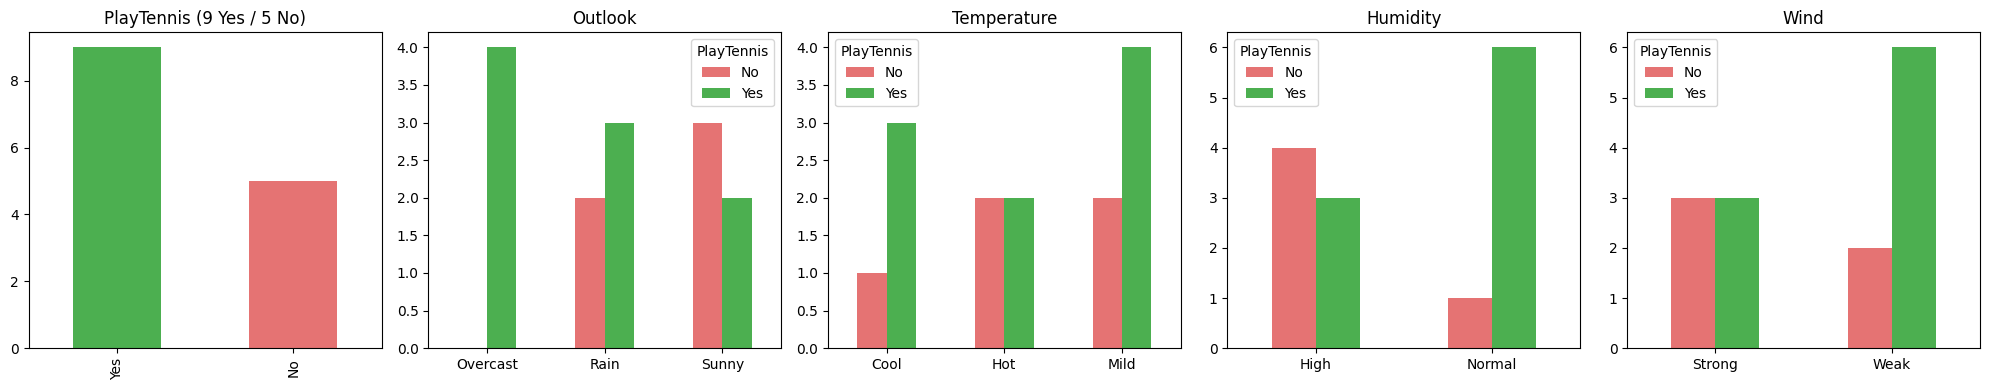

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
df[TARGET].value_counts().plot(kind='bar', ax=axes[0], color=['#4CAF50', '#E57373'])
axes[0].set_title('PlayTennis (9 Yes / 5 No)'); axes[0].set_xlabel('')
for ax, f in zip(axes[1:], FEATURES):
    pd.crosstab(df[f], df[TARGET]).plot(kind='bar', ax=ax, color=['#E57373', '#4CAF50'])
    ax.set_title(f); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

**Observation:** Every *Overcast* day is *Yes*, a strong hint that Outlook will be very informative.

## 4. Helper Functions : Entropy, Information Gain, Gini

In [5]:
def entropy(labels):
    # Entropy(S) = -sum p_i log2 p_i
    counts = np.array(list(Counter(labels).values()))
    p = counts / counts.sum()
    return abs(float(-np.sum(p * np.log2(p))))   # abs() avoids printing -0.0 for pure sets

def gini(labels):
    # Gini(S) = 1 - sum p_i^2
    counts = np.array(list(Counter(labels).values()))
    p = counts / counts.sum()
    return float(1 - np.sum(p ** 2))

def information_gain(data, attribute, target=TARGET, verbose=False):
    total_entropy = entropy(data[target])
    weighted = 0.0
    for value, subset in data.groupby(attribute):
        w = len(subset) / len(data)
        e = entropy(subset[target])
        weighted += w * e
        if verbose:
            c = Counter(subset[target])
            print(f"   {attribute}={value:9s} [{c.get('Yes',0)}+, {c.get('No',0)}-]  "
                  f"Entropy={e:.4f}  weight={len(subset)}/{len(data)}")
    gain = total_entropy - weighted
    if verbose:
        print(f"   Gain(S, {attribute}) = {total_entropy:.4f} - {weighted:.4f} = {gain:.4f}\n")
    return gain

def gini_gain(data, attribute, target=TARGET):
    weighted = sum(len(s) / len(data) * gini(s[target]) for _, s in data.groupby(attribute))
    return gini(data[target]) - weighted

# sanity checks
print("Entropy of pure set  :", entropy(['Yes']*4))
print("Entropy of 50/50 set :", entropy(['Yes','No']*3))
print("Gini of 50/50 set    :", gini(['Yes','No']*3))

Entropy of pure set  : 0.0
Entropy of 50/50 set : 1.0
Gini of 50/50 set    : 0.5


## 5. Step-by-Step Manual Calculation (Root Node)

### 5.1 Entropy of the whole dataset
$S$ has **9 Yes** and **5 No**:

$$Entropy(S) = -\tfrac{9}{14}\log_2\tfrac{9}{14} - \tfrac{5}{14}\log_2\tfrac{5}{14} = 0.940$$

In [6]:
E_S = entropy(df[TARGET])
print(f"Entropy(S) [9+, 5-] = {E_S:.4f}")

Entropy(S) [9+, 5-] = 0.9403


### 5.2 Information Gain of every attribute

In [7]:
root_gains = {}
for f in FEATURES:
    print(f"Attribute: {f}")
    root_gains[f] = information_gain(df, f, verbose=True)

Attribute: Outlook
   Outlook=Overcast  [4+, 0-]  Entropy=0.0000  weight=4/14
   Outlook=Rain      [3+, 2-]  Entropy=0.9710  weight=5/14
   Outlook=Sunny     [2+, 3-]  Entropy=0.9710  weight=5/14
   Gain(S, Outlook) = 0.9403 - 0.6935 = 0.2467

Attribute: Temperature
   Temperature=Cool      [3+, 1-]  Entropy=0.8113  weight=4/14
   Temperature=Hot       [2+, 2-]  Entropy=1.0000  weight=4/14
   Temperature=Mild      [4+, 2-]  Entropy=0.9183  weight=6/14
   Gain(S, Temperature) = 0.9403 - 0.9111 = 0.0292

Attribute: Humidity
   Humidity=High      [3+, 4-]  Entropy=0.9852  weight=7/14
   Humidity=Normal    [6+, 1-]  Entropy=0.5917  weight=7/14
   Gain(S, Humidity) = 0.9403 - 0.7885 = 0.1518

Attribute: Wind
   Wind=Strong    [3+, 3-]  Entropy=1.0000  weight=6/14
   Wind=Weak      [6+, 2-]  Entropy=0.8113  weight=8/14
   Gain(S, Wind) = 0.9403 - 0.8922 = 0.0481



,Information Gain
Outlook,0.2467
Humidity,0.1518
Wind,0.0481
Temperature,0.0292


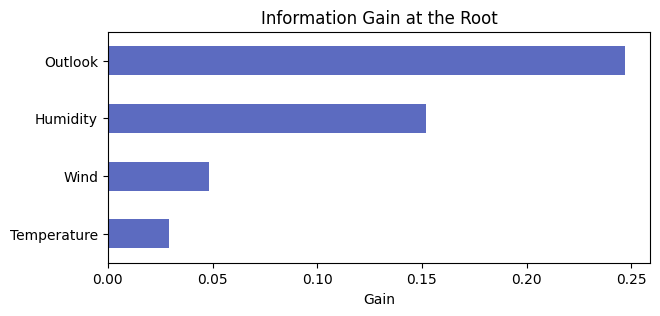

✅ Root node = Outlook  (highest gain = 0.2467)


In [8]:
gain_table = pd.DataFrame({'Information Gain': root_gains}).sort_values('Information Gain', ascending=False)
display(gain_table.round(4))

gain_table.plot(kind='barh', legend=False, color='#5C6BC0', figsize=(7, 3))
plt.title('Information Gain at the Root'); plt.xlabel('Gain'); plt.gca().invert_yaxis(); plt.show()

root = gain_table.index[0]
print(f"✅ Root node = {root}  (highest gain = {gain_table.iloc[0,0]:.4f})")

| Attribute | Gain |
|---|---|
| **Outlook** | **0.246** ← chosen |
| Humidity | 0.151 |
| Wind | 0.048 |
| Temperature | 0.029 |

**Outlook** becomes the root. It creates three branches: *Sunny*, *Overcast*, *Rain*.

## 6. Growing the Tree : Second Level

### 6.1 Branch Outlook = Overcast

In [9]:
overcast = df[df.Outlook == 'Overcast']
display(overcast)
print(f"Entropy = {entropy(overcast[TARGET]):.4f}  → pure, becomes a LEAF: Yes")

,Day,Outlook,Temperature,Humidity,Wind,PlayTennis
2,D3,Overcast,Hot,High,Weak,Yes
6,D7,Overcast,Cool,Normal,Strong,Yes
11,D12,Overcast,Mild,High,Strong,Yes
12,D13,Overcast,Hot,Normal,Weak,Yes


Entropy = 0.0000  → pure, becomes a LEAF: Yes


### 6.2 Branch Outlook = Sunny  (remaining attributes: Temperature, Humidity, Wind)

In [10]:
sunny = df[df.Outlook == 'Sunny']
display(sunny)
print(f"Entropy(S_sunny) = {entropy(sunny[TARGET]):.4f}\n")
sunny_gains = {f: information_gain(sunny, f, verbose=True) for f in ['Temperature','Humidity','Wind']}
best = max(sunny_gains, key=sunny_gains.get)
print(f"✅ Best attribute under Sunny = {best} (gain {sunny_gains[best]:.4f})")

,Day,Outlook,Temperature,Humidity,Wind,PlayTennis
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
10,D11,Sunny,Mild,Normal,Strong,Yes


Entropy(S_sunny) = 0.9710

   Temperature=Cool      [1+, 0-]  Entropy=0.0000  weight=1/5
   Temperature=Hot       [0+, 2-]  Entropy=0.0000  weight=2/5
   Temperature=Mild      [1+, 1-]  Entropy=1.0000  weight=2/5
   Gain(S, Temperature) = 0.9710 - 0.4000 = 0.5710

   Humidity=High      [0+, 3-]  Entropy=0.0000  weight=3/5
   Humidity=Normal    [2+, 0-]  Entropy=0.0000  weight=2/5
   Gain(S, Humidity) = 0.9710 - 0.0000 = 0.9710

   Wind=Strong    [1+, 1-]  Entropy=1.0000  weight=2/5
   Wind=Weak      [1+, 2-]  Entropy=0.9183  weight=3/5
   Gain(S, Wind) = 0.9710 - 0.9510 = 0.0200

✅ Best attribute under Sunny = Humidity (gain 0.9710)


Humidity splits the Sunny days **perfectly**: High → No, Normal → Yes (gain 0.971 = the full entropy).

### 6.3 Branch Outlook = Rain  (remaining attributes: Temperature, Humidity, Wind)

In [11]:
rain = df[df.Outlook == 'Rain']
display(rain)
print(f"Entropy(S_rain) = {entropy(rain[TARGET]):.4f}\n")
rain_gains = {f: information_gain(rain, f, verbose=True) for f in ['Temperature','Humidity','Wind']}
best = max(rain_gains, key=rain_gains.get)
print(f"✅ Best attribute under Rain = {best} (gain {rain_gains[best]:.4f})")

,Day,Outlook,Temperature,Humidity,Wind,PlayTennis
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
9,D10,Rain,Mild,Normal,Weak,Yes
13,D14,Rain,Mild,High,Strong,No


Entropy(S_rain) = 0.9710

   Temperature=Cool      [1+, 1-]  Entropy=1.0000  weight=2/5
   Temperature=Mild      [2+, 1-]  Entropy=0.9183  weight=3/5
   Gain(S, Temperature) = 0.9710 - 0.9510 = 0.0200

   Humidity=High      [1+, 1-]  Entropy=1.0000  weight=2/5
   Humidity=Normal    [2+, 1-]  Entropy=0.9183  weight=3/5
   Gain(S, Humidity) = 0.9710 - 0.9510 = 0.0200

   Wind=Strong    [0+, 2-]  Entropy=0.0000  weight=2/5
   Wind=Weak      [3+, 0-]  Entropy=0.0000  weight=3/5
   Gain(S, Wind) = 0.9710 - 0.0000 = 0.9710

✅ Best attribute under Rain = Wind (gain 0.9710)


Wind splits the Rain days **perfectly**: Strong → No, Weak → Yes. All leaves are now pure, so the tree is complete.

## 7. ID3 Algorithm : Full Implementation From Scratch

In [12]:
def id3(data, target, attributes, parent_majority=None, depth=0, log=True):
    labels = data[target]

    # Case: empty subset → majority of parent
    if len(data) == 0:
        return parent_majority
    # Case 1: all examples same class → leaf
    if labels.nunique() == 1:
        return labels.iloc[0]
    majority = labels.mode()[0]
    # Case 2: no attributes left → majority leaf
    if len(attributes) == 0:
        return majority

    # Step 3: pick attribute with highest information gain
    gains = {a: information_gain(data, a, target) for a in attributes}
    best = max(gains, key=gains.get)
    if log:
        print("   " * depth + f"Split on '{best}' (gain={gains[best]:.4f}) | n={len(data)}")

    tree = {best: {}}
    remaining = [a for a in attributes if a != best]
    for value in sorted(df[best].unique()):              # all possible values of the attribute
        subset = data[data[best] == value]
        tree[best][value] = id3(subset, target, remaining, majority, depth + 1, log)
    return tree

print("Building tree with ID3...\n")
id3_tree = id3(df, TARGET, FEATURES)
print("\nFinal tree (nested dictionary):")
pprint(id3_tree)

Building tree with ID3...

Split on 'Outlook' (gain=0.2467) | n=14
   Split on 'Wind' (gain=0.9710) | n=5
   Split on 'Humidity' (gain=0.9710) | n=5

Final tree (nested dictionary):
{'Outlook': {'Overcast': 'Yes',
             'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}},
             'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}


### 7.1 Text view of the tree

In [13]:
def print_tree(tree, indent=""):
    if not isinstance(tree, dict):
        print(indent + "→ " + str(tree)); return
    attr = next(iter(tree))
    for value, sub in tree[attr].items():
        if isinstance(sub, dict):
            print(f"{indent}[{attr} = {value}]")
            print_tree(sub, indent + "    ")
        else:
            print(f"{indent}[{attr} = {value}] → {sub}")

print_tree(id3_tree)

[Outlook = Overcast] → Yes
[Outlook = Rain]
    [Wind = Strong] → No
    [Wind = Weak] → Yes
[Outlook = Sunny]
    [Humidity = High] → No
    [Humidity = Normal] → Yes


### 7.2 Graphical view of the ID3 tree

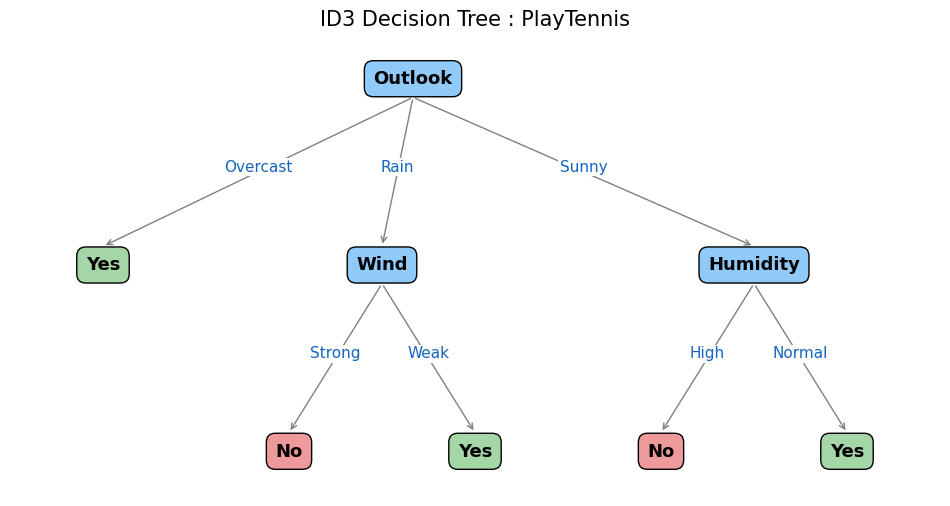

In [14]:
def draw_tree(tree, title="ID3 Decision Tree : PlayTennis"):
    fig, ax = plt.subplots(figsize=(12, 6)); ax.axis('off')

    def leaves(t):
        return 1 if not isinstance(t, dict) else sum(leaves(s) for s in t[next(iter(t))].values())

    def depth(t):
        return 0 if not isinstance(t, dict) else 1 + max(depth(s) for s in t[next(iter(t))].values())

    D = depth(tree); total = leaves(tree); cursor = [0]

    def plot(t, level):
        y = 1 - level / D
        if not isinstance(t, dict):
            x = (cursor[0] + 0.5) / total; cursor[0] += 1
            col = '#A5D6A7' if t == 'Yes' else '#EF9A9A'
            ax.text(x, y, t, ha='center', va='center', fontsize=13, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', fc=col, ec='black'))
            return x, y
        attr = next(iter(t)); kids = []
        for val, sub in t[attr].items():
            kids.append((val, *plot(sub, level + 1)))
        x = np.mean([k[1] for k in kids])
        for val, cx, cy in kids:
            ax.annotate('', xy=(cx, cy + 0.05), xytext=(x, y - 0.05),
                        arrowprops=dict(arrowstyle='->', color='gray'))
            ax.text((x + cx) / 2, (y + cy) / 2, val, ha='center', fontsize=11, color='#1565C0',
                    bbox=dict(fc='white', ec='none', pad=1))
        ax.text(x, y, attr, ha='center', va='center', fontsize=13, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', fc='#90CAF9', ec='black'))
        return x, y

    plot(tree, 0)
    ax.set_ylim(-0.12, 1.12); ax.set_title(title, fontsize=15)
    plt.show()

draw_tree(id3_tree)

**Interpretation:** Only **3 of the 4 attributes** are needed. *Temperature* never appears, because once Outlook, Humidity and Wind are known the answer is already certain. This is ID3's inductive bias at work: it prefers **shorter trees** with high-gain attributes near the root.

## 8. Extracting IF–THEN Rules

In [15]:
def extract_rules(tree, conditions=None):
    conditions = conditions or []
    if not isinstance(tree, dict):
        return [(conditions, tree)]
    attr = next(iter(tree)); rules = []
    for value, sub in tree[attr].items():
        rules += extract_rules(sub, conditions + [f"{attr} = {value}"])
    return rules

for i, (conds, label) in enumerate(extract_rules(id3_tree), 1):
    print(f"Rule {i}: IF {' AND '.join(conds)} THEN PlayTennis = {label}")

Rule 1: IF Outlook = Overcast THEN PlayTennis = Yes
Rule 2: IF Outlook = Rain AND Wind = Strong THEN PlayTennis = No
Rule 3: IF Outlook = Rain AND Wind = Weak THEN PlayTennis = Yes
Rule 4: IF Outlook = Sunny AND Humidity = High THEN PlayTennis = No
Rule 5: IF Outlook = Sunny AND Humidity = Normal THEN PlayTennis = Yes


## 9. Prediction Using the ID3 Tree

In [16]:
def predict(tree, sample, default='Yes'):
    while isinstance(tree, dict):
        attr = next(iter(tree))
        value = sample.get(attr)
        if value not in tree[attr]:
            return default                      # unseen attribute value
        tree = tree[attr][value]
    return tree

# Training accuracy
df['ID3_Prediction'] = df.apply(lambda r: predict(id3_tree, r.to_dict()), axis=1)
display(df[['Day'] + FEATURES + [TARGET, 'ID3_Prediction']])
print(f"Training accuracy = {accuracy_score(df[TARGET], df['ID3_Prediction'])*100:.1f}%")

,Day,Outlook,Temperature,Humidity,Wind,PlayTennis,ID3_Prediction
0,D1,Sunny,Hot,High,Weak,No,No
1,D2,Sunny,Hot,High,Strong,No,No
2,D3,Overcast,Hot,High,Weak,Yes,Yes
3,D4,Rain,Mild,High,Weak,Yes,Yes
4,D5,Rain,Cool,Normal,Weak,Yes,Yes
5,D6,Rain,Cool,Normal,Strong,No,No
6,D7,Overcast,Cool,Normal,Strong,Yes,Yes
7,D8,Sunny,Mild,High,Weak,No,No
8,D9,Sunny,Cool,Normal,Weak,Yes,Yes
9,D10,Rain,Mild,Normal,Weak,Yes,Yes


Training accuracy = 100.0%


### 9.1 Predicting new (unseen) days

In [17]:
new_days = pd.DataFrame([
    {'Outlook': 'Sunny',    'Temperature': 'Cool', 'Humidity': 'High',   'Wind': 'Strong'},   # Mitchell's textbook query
    {'Outlook': 'Rain',     'Temperature': 'Hot',  'Humidity': 'Normal', 'Wind': 'Weak'},
    {'Outlook': 'Overcast', 'Temperature': 'Cool', 'Humidity': 'High',   'Wind': 'Strong'},
    {'Outlook': 'Sunny',    'Temperature': 'Mild', 'Humidity': 'Normal', 'Wind': 'Weak'},
])
new_days['Predicted PlayTennis'] = new_days.apply(lambda r: predict(id3_tree, r.to_dict()), axis=1)
new_days

,Outlook,Temperature,Humidity,Wind,Predicted PlayTennis
0,Sunny,Cool,High,Strong,No
1,Rain,Hot,Normal,Weak,Yes
2,Overcast,Cool,High,Strong,Yes
3,Sunny,Mild,Normal,Weak,Yes


For the textbook query ⟨Sunny, Cool, High, Strong⟩ the tree goes **Outlook = Sunny → Humidity = High → No**.

## 10. Decision Tree Using scikit-learn

scikit-learn needs **numbers**, so we **one-hot encode** the categorical attributes.

**Important difference:** sklearn implements an optimised **CART** algorithm, which builds **binary** trees (each node asks a yes/no question such as *Outlook_Overcast ≤ 0.5*), while ID3 creates one branch per attribute value. The tree shape therefore looks different, but the logic learned is equivalent.

In [18]:
X = pd.get_dummies(df[FEATURES]).astype(int)
y = df[TARGET]
print("Encoded feature columns:", list(X.columns))
X.head()

Encoded feature columns: ['Outlook_Overcast', 'Outlook_Rain', 'Outlook_Sunny', 'Temperature_Cool', 'Temperature_Hot', 'Temperature_Mild', 'Humidity_High', 'Humidity_Normal', 'Wind_Strong', 'Wind_Weak']


,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal,Wind_Strong,Wind_Weak
0,0,0,1,0,1,0,1,0,0,1
1,0,0,1,0,1,0,1,0,1,0
2,1,0,0,0,1,0,1,0,0,1
3,0,1,0,0,0,1,1,0,0,1
4,0,1,0,1,0,0,0,1,0,1


### 10.1 Entropy criterion (closest to ID3)

In [19]:
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=SEED)
clf_entropy.fit(X, y)

print("Depth:", clf_entropy.get_depth(), "| Leaves:", clf_entropy.get_n_leaves())
print("Training accuracy:", accuracy_score(y, clf_entropy.predict(X)))
print("\n" + export_text(clf_entropy, feature_names=list(X.columns)))

Depth:

 4 | Leaves: 7
Training accuracy: 1.0

|--- Outlook_Overcast <= 0.50
|   |--- Humidity_High <= 0.50
|   |   |--- Wind_Strong <= 0.50
|   |   |   |--- class: Yes
|   |   |--- Wind_Strong >  0.50
|   |   |   |--- Outlook_Rain <= 0.50
|   |   |   |   |--- class: Yes
|   |   |   |--- Outlook_Rain >  0.50
|   |   |   |   |--- class: No
|   |--- Humidity_High >  0.50
|   |   |--- Outlook_Rain <= 0.50
|   |   |   |--- class: No
|   |   |--- Outlook_Rain >  0.50
|   |   |   |--- Wind_Weak <= 0.50
|   |   |   |   |--- class: No
|   |   |   |--- Wind_Weak >  0.50
|   |   |   |   |--- class: Yes
|--- Outlook_Overcast >  0.50
|   |--- class: Yes



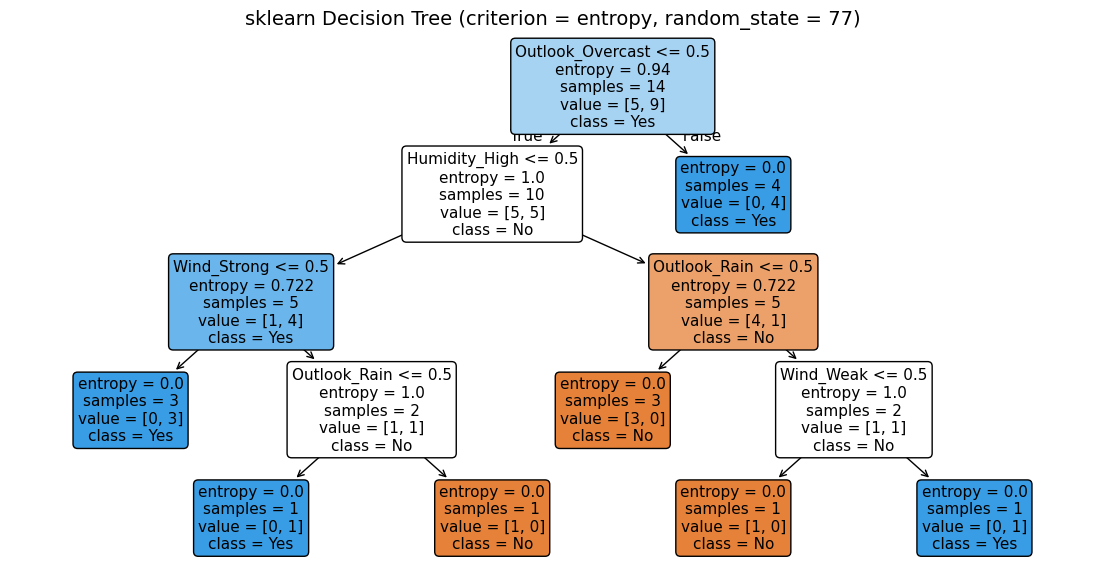

In [20]:
plt.figure(figsize=(14, 7))
plot_tree(clf_entropy, feature_names=X.columns, class_names=clf_entropy.classes_,
          filled=True, rounded=True, fontsize=11)
plt.title("sklearn Decision Tree (criterion = entropy, random_state = 77)", fontsize=14)
plt.show()

### 10.2 Gini criterion (sklearn default)

Depth: 4 | Leaves: 7


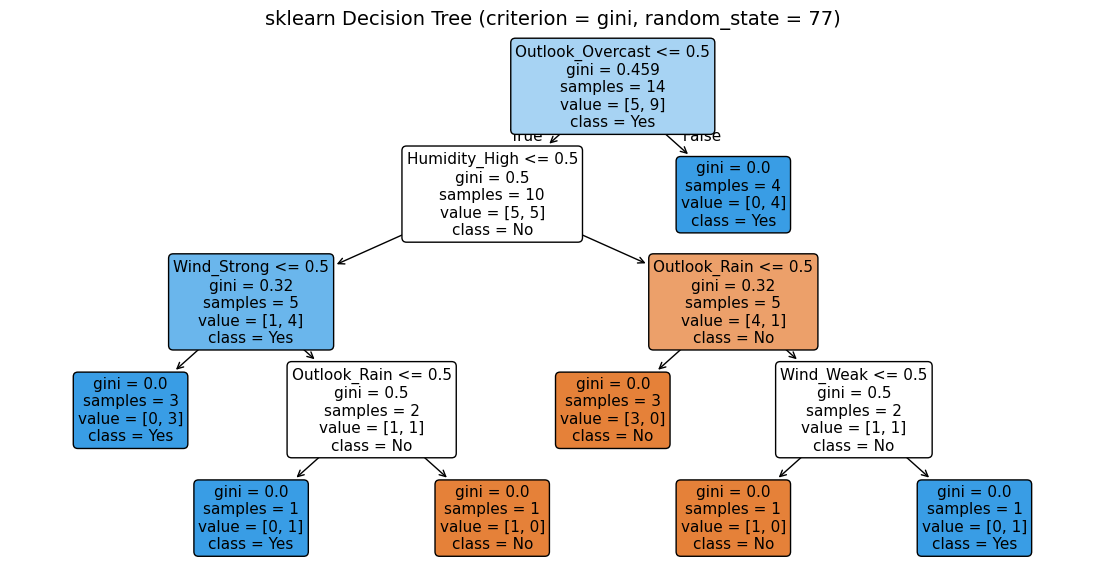

In [21]:
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=SEED)
clf_gini.fit(X, y)
print("Depth:", clf_gini.get_depth(), "| Leaves:", clf_gini.get_n_leaves())

plt.figure(figsize=(14, 7))
plot_tree(clf_gini, feature_names=X.columns, class_names=clf_gini.classes_,
          filled=True, rounded=True, fontsize=11)
plt.title("sklearn Decision Tree (criterion = gini, random_state = 77)", fontsize=14)
plt.show()

### 10.3 Entropy vs Gini at the root (manual)

In [22]:
comparison = pd.DataFrame({
    'Information Gain (Entropy)': {f: information_gain(df, f) for f in FEATURES},
    'Gini Gain':                  {f: gini_gain(df, f) for f in FEATURES},
}).sort_values('Information Gain (Entropy)', ascending=False)
print(f"Gini(S) = {gini(df[TARGET]):.4f}   Entropy(S) = {entropy(df[TARGET]):.4f}\n")
comparison.round(4)

Gini(S) = 0.4592   Entropy(S) = 0.9403



,Information Gain (Entropy),Gini Gain
Outlook,0.2467,0.1163
Humidity,0.1518,0.0918
Wind,0.0481,0.0306
Temperature,0.0292,0.0187


Both measures rank **Outlook first**, so for this dataset Entropy and Gini agree on the most important attribute.

### 10.4 Feature importance

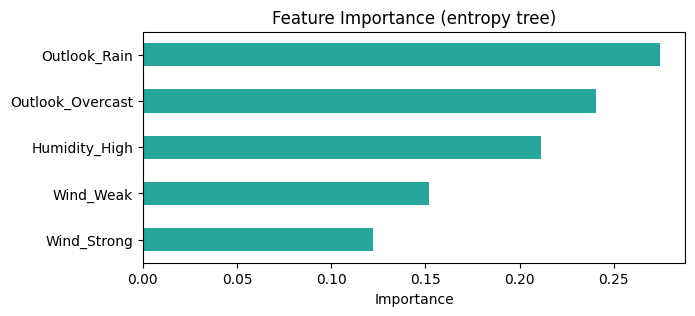

Outlook_Rain        0.2742
Outlook_Overcast    0.2404
Humidity_High       0.2112
Wind_Weak           0.1519
Wind_Strong         0.1223
dtype: float64

In [23]:
imp = pd.Series(clf_entropy.feature_importances_, index=X.columns).sort_values()
imp[imp > 0].plot(kind='barh', color='#26A69A', figsize=(7, 3))
plt.title('Feature Importance (entropy tree)'); plt.xlabel('Importance'); plt.show()
imp[imp > 0].sort_values(ascending=False).round(4)

### 10.5 Predicting the new days with sklearn

In [24]:
X_new = pd.get_dummies(new_days[FEATURES]).reindex(columns=X.columns, fill_value=0).astype(int)
new_days['sklearn (entropy)'] = clf_entropy.predict(X_new)
new_days['sklearn (gini)'] = clf_gini.predict(X_new)
new_days

,Outlook,Temperature,Humidity,Wind,Predicted PlayTennis,sklearn (entropy),sklearn (gini)
0,Sunny,Cool,High,Strong,No,No,No
1,Rain,Hot,Normal,Weak,Yes,Yes,Yes
2,Overcast,Cool,High,Strong,Yes,Yes,Yes
3,Sunny,Mild,Normal,Weak,Yes,Yes,Yes


## 11. Model Evaluation

Training accuracy of 100% is expected (the tree memorises all 14 rows) but says nothing about generalisation. With only 14 examples a train/test split would be unreliable, so we use **Leave-One-Out Cross-Validation (LOOCV)**: train on 13, test on the 1 left out, repeat 14 times.

In [25]:
loo = LeaveOneOut()

# ID3 (from scratch) with LOOCV
id3_preds = []
for train_idx, test_idx in loo.split(df):
    t = id3(df.iloc[train_idx], TARGET, FEATURES, log=False)
    id3_preds.append(predict(t, df.iloc[test_idx[0]].to_dict(), default=df.iloc[train_idx][TARGET].mode()[0]))

sk_preds = cross_val_predict(DecisionTreeClassifier(criterion='entropy', random_state=SEED), X, y, cv=loo)

print(f"LOOCV accuracy : ID3 (scratch) = {accuracy_score(y, id3_preds)*100:.2f}%")
print(f"LOOCV accuracy : sklearn       = {accuracy_score(y, sk_preds)*100:.2f}%\n")
print("Classification report (sklearn, LOOCV):")
print(classification_report(y, sk_preds, zero_division=0))

LOOCV accuracy : ID3 (scratch) = 78.57%
LOOCV accuracy : sklearn       = 57.14%

Classification report (sklearn, LOOCV):
              precision    recall  f1-score   support

          No       0.40      0.40      0.40         5
         Yes       0.67      0.67      0.67         9

    accuracy                           0.57        14
   macro avg       0.53      0.53      0.53        14
weighted avg       0.57      0.57      0.57        14



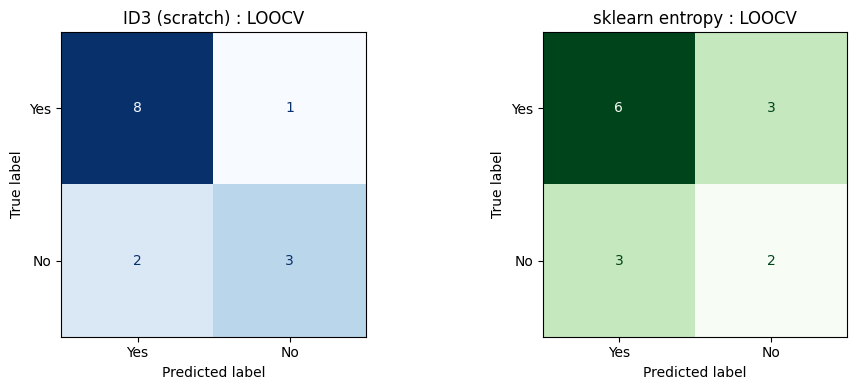

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y, id3_preds, labels=['Yes','No']), display_labels=['Yes','No']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('ID3 (scratch) : LOOCV')
ConfusionMatrixDisplay(confusion_matrix(y, sk_preds, labels=['Yes','No']), display_labels=['Yes','No']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('sklearn entropy : LOOCV')
plt.tight_layout(); plt.show()

The drop from 100% (training) to the LOOCV score shows how much a fully grown tree **overfits** a tiny dataset.

## 12. Overfitting and Pruning

A tree that keeps splitting until every leaf is pure fits noise in the training data. Common controls:

| Technique | sklearn parameter | Idea |
|---|---|---|
| Pre-pruning | `max_depth`, `min_samples_split`, `min_samples_leaf` | Stop growing early |
| Post-pruning | `ccp_alpha` (cost-complexity) | Grow fully, then cut weak branches |
| Reduced-error pruning | (manual) | Remove nodes if validation accuracy doesn't drop |

,max_depth,Train acc,LOOCV acc,Leaves
0,1,0.643,0.143,2
1,2,0.857,0.571,3
2,3,0.857,0.643,5
3,None (full),1.000,0.571,7


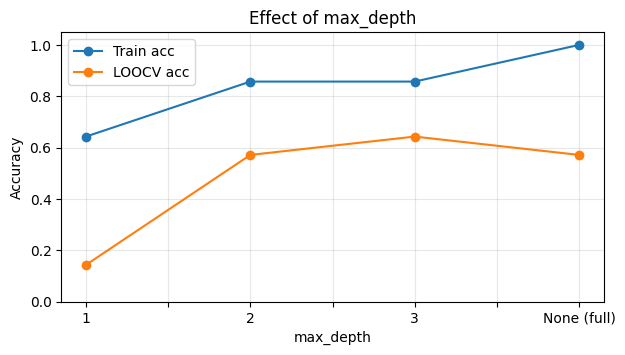

In [27]:
rows = []
for d in [1, 2, 3, None]:
    m = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=SEED)
    train_acc = accuracy_score(y, m.fit(X, y).predict(X))
    loo_acc = accuracy_score(y, cross_val_predict(m, X, y, cv=loo))
    rows.append({'max_depth': 'None (full)' if d is None else d, 'Train acc': train_acc, 'LOOCV acc': loo_acc,
                 'Leaves': m.get_n_leaves()})
depth_df = pd.DataFrame(rows)
display(depth_df.round(3))

depth_df.set_index('max_depth')[['Train acc', 'LOOCV acc']].plot(marker='o', figsize=(7, 3.5))
plt.title('Effect of max_depth'); plt.ylabel('Accuracy'); plt.ylim(0, 1.05); plt.grid(alpha=.3); plt.show()

In [28]:
path = DecisionTreeClassifier(criterion='entropy', random_state=SEED).cost_complexity_pruning_path(X, y)
print("Effective alphas:", np.round(path.ccp_alphas, 4))
for a in path.ccp_alphas:
    m = DecisionTreeClassifier(criterion='entropy', ccp_alpha=a, random_state=SEED).fit(X, y)
    print(f"ccp_alpha={a:.4f} → leaves={m.get_n_leaves()}, train acc={accuracy_score(y, m.predict(X)):.3f}")

Effective alphas: [0.     0.1289 0.1289 0.1986 0.226 ]
ccp_alpha=0.0000 → leaves=7, train acc=1.000
ccp_alpha=0.1289 → leaves=3, train acc=0.857
ccp_alpha=0.1289 → leaves=3, train acc=0.857
ccp_alpha=0.1986 → leaves=2, train acc=0.643
ccp_alpha=0.2260 → leaves=1, train acc=0.643


## 13. Conclusion

- **Entropy(S) = 0.940** for the 9 Yes / 5 No dataset.
- **Outlook** has the highest information gain (**0.246**) and becomes the root.
- Under *Sunny* the best split is **Humidity**; under *Rain* it is **Wind**; *Overcast* is always **Yes**.
- The final ID3 tree uses only 3 attributes and yields 5 IF–THEN rules; **Temperature is irrelevant**.
- The from-scratch ID3 and scikit-learn trees give identical predictions on the new days, though sklearn's tree is **binary** (CART) because of one-hot encoding.
- Entropy and Gini both rank Outlook as the most informative attribute.
- Training accuracy is 100%, but LOOCV drops to about 79% (ID3) and 57% (sklearn binary tree), showing overfitting on a tiny dataset and motivating **pruning** and depth limits.

### Advantages of Decision Trees
Easy to interpret, handle categorical data naturally, need no feature scaling, produce human-readable rules.

### Limitations
Prone to overfitting, unstable (small data changes can alter the tree), greedy splitting is not globally optimal, information gain is biased toward attributes with many values (fixed by **Gain Ratio** in C4.5).

## 14. Viva Questions

**Q1. Why is Outlook chosen as the root?**  
It gives the largest reduction in entropy (gain 0.246), meaning it separates Yes/No days better than any other attribute.

**Q2. What does entropy = 0 mean?**  
The node is pure: all examples belong to one class, so it becomes a leaf.

**Q3. What is the inductive bias of ID3?**  
It prefers shorter trees and places high-information-gain attributes closer to the root (Occam's razor).

**Q4. Difference between ID3, C4.5 and CART?**  
ID3 uses information gain and multiway splits on categorical data. C4.5 uses gain ratio, handles continuous values and missing data, and prunes. CART uses Gini, builds binary trees, and supports regression.

**Q5. Why does Temperature not appear in the tree?**  
After splitting on Outlook, Humidity and Wind, every leaf is already pure, so Temperature adds no information.

**Q6. How do you prevent overfitting in decision trees?**  
Pre-pruning (max depth, minimum samples per leaf) or post-pruning (cost-complexity / reduced-error pruning), and using ensembles like Random Forest.